# 01 — Data Preparation: Contacts

**Project:** CRM Analytics & Unit Economics of an online programming school

This notebook cleans and prepares the **contacts** dataset (lead records): deduplication, validation, and descriptive statistics. Output is saved to `data/processed/`.

*Analysis commentary inside is in Russian; see the project README for a full English summary of methods and findings.*

---
## 1. Импорты и настройки

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

import utils as h

In [2]:
# Настройки визуализации
sns.set_style('whitegrid')
sns.set_palette('deep')

# Настройки pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Пути (ноутбук лежит в notebooks/, данные в data/)
PROJECT_ROOT = Path().resolve().parent
RAW          = PROJECT_ROOT / 'data' / 'raw'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
BACKUP       = PROJECT_ROOT / 'data' / 'processed' / 'backup'
IMAGES       = PROJECT_ROOT / 'images'

# Создаём папку backup если её ещё нет
BACKUP.mkdir(parents=True, exist_ok=True)

---
## 2. Конфигурация настроек для датасета

Заполните `name` и `filename` **до запуска** остальных ячеек.  


In [3]:
# ── КОНФИГ ДАТАСЕТА ──────────────────────────────────────────────────────────
# Заполните name и filename - остальное после предварительного анализа

dataset_config = {

    # Короткое имя датасета (латиницей, без пробелов)
    # Используется как имя файла при сохранении конфига и бэкапа
    # Примеры: 'deals', 'contacts', 'calls', 'spend'
    'name':       'contacts',

    # Имя исходного файла в папке data/raw/
    'filename':   'Contacts (Done).xlsx',

}

print(f"Датасет: {dataset_config['name']}")
print(f"Файл:    {dataset_config['filename']}")

Датасет: contacts
Файл:    Contacts (Done).xlsx


---
## 3. Загрузка данных

In [4]:
# Загрузка датасета по имени файла из конфига
filepath = RAW / dataset_config['filename']

if filepath.suffix == '.xlsx':
    df = pd.read_excel(
        filepath,
        dtype={
            'Id': 'string'
        }
    )
else:
    raise ValueError(f"Неизвестный формат файла: {filepath.suffix}")

print(f"Загружен: {dataset_config['filename']}")
print(f"Размер:   {df.shape[0]} строк × {df.shape[1]} столбцов")

Загружен: Contacts (Done).xlsx
Размер:   18548 строк × 4 столбцов


### 📥 Загрузка данных

Датасет содержит информацию о контактах из CRM-системы.

Он будет использоваться как справочник для объединения:
- звонков (calls),
- сделок (deals).

Ключевым полем является `id`.

---
## 4. Предварительный анализ

Смотрим на данные - что там вообще есть.  
После этого раздела заполните типы столбцов в Разделе 5.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18548 entries, 0 to 18547
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  18548 non-null  string
 1   Contact Owner Name  18548 non-null  object
 2   Created Time        18548 non-null  object
 3   Modified Time       18548 non-null  object
dtypes: object(3), string(1)
memory usage: 579.8+ KB


In [6]:
# Первые строки
df.head()

,Id,Contact Owner Name,Created Time,Modified Time
0,5805028000000645014,Rachel White,27.06.2023 11:28,22.12.2023 13:34
1,5805028000000872003,Charlie Davis,03.07.2023 11:31,21.05.2024 10:23
2,5805028000000889001,Bob Brown,02.07.2023 22:37,21.12.2023 13:17
3,5805028000000907006,Bob Brown,03.07.2023 05:44,29.12.2023 15:20
4,5805028000000939010,Nina Scott,04.07.2023 10:11,16.04.2024 16:14


In [7]:
# # Переименование столбцов: убираем пробелы и скобки, приводим к snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

print("Столбцы после переименования:")
print(df.columns.tolist())

Столбцы после переименования:
['id', 'contact_owner_name', 'created_time', 'modified_time']


In [8]:
df.describe(include='all')

,id,contact_owner_name,created_time,modified_time
count,18548,18548,18548,18548
unique,18548,28,17921,16580
top,5805028000000645014,Charlie Davis,10.06.2024 09:00,13.06.2024 17:08
freq,1,2018,13,25


In [9]:
# Сводная таблица по числовым столбцам 
h.descr_df(df)

В датасете нет колонок с типом данных: number


In [10]:
# Сводная таблица по всем столбцам 
h.descr_df(df, include=['object'], show_stats=False, show_sample_rows=True)

,Название признака,Тип данных,Количество значений,Пропуски (NaN),Уникальных значений,Пример строка 1,Пример строка 2,Пример строка 3
0,contact_owner_name,object,18548,0,28,Rachel White,Charlie Davis,Bob Brown
1,created_time,object,18548,0,17921,27.06.2023 11:28,03.07.2023 11:31,02.07.2023 22:37
2,modified_time,object,18548,0,16580,22.12.2023 13:34,21.05.2024 10:23,21.12.2023 13:17


In [11]:
# Пропущенные значения - первый взгляд
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'пропуски': missing, '%': missing_pct})
missing_df = missing_df.query('пропуски > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("Пропущенных значений нет")
else:
    display(missing_df)

Пропущенных значений нет


In [12]:
# Дубликаты полные - первый взгляд
n_dups = df.duplicated().sum()
print(f"Дубликатов строк: {n_dups}")

Дубликатов строк: 0


In [13]:
# Удаляем полные дубликаты
df = df.drop_duplicates().reset_index(drop=True)

print(f"После удаления полных дублей: {df.shape}")

После удаления полных дублей: (18548, 4)


In [14]:
# Проверка дублей по id (ключевое поле)
dup_id = df[df['id'].duplicated(keep=False)]

print(f"Количество строк с дублирующимся id: {dup_id.shape[0]}")
display(dup_id.head())

Количество строк с дублирующимся id: 0


,id,contact_owner_name,created_time,modified_time


### 📊 Общий анализ таблицы `Contacts` (Описательная статистика)

Эта таблица — "входная дверь" нашей CRM. Здесь хранятся уникальные записи о людях, которые когда-либо взаимодействовали со школой.

#### 📝 Микровывод

1. **Идеальная уникальность:** Столбец `id` содержит **18 548 уникальных значений** на 18 548 строк. 
   * *Что это значит:* У нас нет дубликатов на уровне сущности контакта. Каждый ID — это отдельный человек. Это отличная новость для "джойна" с таблицей сделок: мы не получим лишних строк.
2. **Лидеры по контактам:** Среди владельцев (`contact_owner_name`) лидером снова является **Charlie Davis** (2018 контактов). 
   * *Инсайт:* Если в Deals мы видели, что он один из лидеров по продажам, то здесь мы видим, что он же обрабатывает и самый большой объем входящих контактов. Это "универсальный солдат" отдела продаж.
3. **Разнообразие владельцев:** Всего зафиксировано **28 уникальных имен**. 
   * *На заметку:* В сделках (`Deals`) их было 18. Это значит, что есть 10 человек, которые заводят контакты в базу (возможно, администраторы или ассистенты), но сами сделки до оплаты не доводят.
4. **Плотность изменений:** У нас **16 580 уникальных меток времени изменения** (`modified_time`). 
   * *Вывод:* Контакты живут активной жизнью. Почти каждый лид проходил через какие-то изменения (смена статуса, добавление комментария) совсем недавно. Топ-дата модификации (13 июня 2024) подтверждает, что с базой активно работали прямо перед выгрузкой.

#### 🛠 Решения
* **Синхронизация:** Использовать этот `id` как ключ для объединения с таблицей `Deals`.
* **Временной анализ:** Создать признак `time_since_last_mod`, чтобы понять, сколько контактов "зависли" без правок более чем на месяц. Это поможет отделу продаж найти "забытых" клиентов.
* **Группировка менеджеров:** Как и в сделках, здесь стоит объединить редких владельцев контактов (тех самых 10 дополнительных человек) в группу `other_owners`, если их доля меньше 1%.

**Инсайты:**

Предварительный анализ показал, что датасет контактов имеет очень высокое качество данных:

- пропущенные значения отсутствуют;
- полные дубликаты строк отсутствуют;
- идентификатор `id` уникален для всех наблюдений.

Это означает, что таблица может использоваться как надёжный справочник контактов и как связующее звено при объединении таблиц звонков и сделок.

---
## 5. Уточнение конфига: типы столбцов

Заполните списки на основе предварительного анализа выше.  
После заполнения запустите ячейку - конфиг сохранится.

In [15]:
num_cols = list(df.select_dtypes(include='number').columns)
print(num_cols)

[]


In [16]:
cat_cols = list(df.select_dtypes(include='object').columns)
print(cat_cols)

['contact_owner_name', 'created_time', 'modified_time']


In [17]:
bool_cols = list(df.select_dtypes(include='bool').columns)
print(bool_cols)

[]


In [18]:
date_cols = list(df.select_dtypes(include='datetime').columns)
print(date_cols)

[]


In [19]:
# # Заполните списки по результатам Раздела 4 ОДИН РАЗ , затем выполните код и закомментируйте его
# # # Если столбец уже был загружен из сохранённого конфига - можно оставить как есть

dataset_config['num_cols'] = []

dataset_config['cat_cols'] = []

dataset_config['bool_cols'] = []

dataset_config['date_cols'] = [
    'created_time',
    'modified_time'
]

dataset_config['drop_cols'] = []

# id отдельно
dataset_config['id_cols'] = ['id']

print("Конфиг обновлён:")
for key, val in dataset_config.items():
    print(f"{key}: {val}")

Конфиг обновлён:
name: contacts
filename: Contacts (Done).xlsx
num_cols: []
cat_cols: []
bool_cols: []
date_cols: ['created_time', 'modified_time']
drop_cols: []
id_cols: ['id']


**Инсайты:**

Для датасета контактов конфигурация получилась минимальной:

- числовые признаки отсутствуют;
- категориальные признаки для отдельного анализа не выделяются;
- ключевым идентификатором является `id`;
- датовые признаки — `created_time` и `modified_time`.

Такая структура соответствует роли датасета: это не аналитическая витрина, а справочник для объединения с другими таблицами проекта.

In [20]:
# Задаем путь для сохранения файла конфигурации
config_path = PROCESSED / f"{dataset_config['name']}_config.pkl"

# Сохраняем обновлённый конфиг
with open(config_path, 'wb') as f:
    pickle.dump(dataset_config, f)

print(f"Конфиг сохранён: {config_path}")
print()
print("Итоговый конфиг:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Конфиг сохранён: E:\ICH\Python Data analyse\crm\data\processed\contacts_config.pkl

Итоговый конфиг:
  name: contacts
  filename: Contacts (Done).xlsx
  num_cols: []
  cat_cols: []
  bool_cols: []
  date_cols: ['created_time', 'modified_time']
  drop_cols: []
  id_cols: ['id']


---
## 6. Преобразование типов данных

In [21]:
# Преобразование дат
for col in dataset_config['date_cols']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f"{col} -> datetime")

created_time -> datetime
modified_time -> datetime


C:\Users\Азат\AppData\Local\Temp\ipykernel_9976\1005117567.py:4: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')
C:\Users\Азат\AppData\Local\Temp\ipykernel_9976\1005117567.py:4: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')


### 📅 Преобразование дат

Столбцы с датами приведены к формату datetime.

Это необходимо для:
- анализа динамики создания контактов,
- корректного объединения с другими таблицами.

In [22]:
# Удаляем ненужные столбцы
if dataset_config['drop_cols']:
    df = df.drop(columns=[c for c in dataset_config['drop_cols'] if c in df.columns])
    print(f"Удалены столбцы: {dataset_config['drop_cols']}")

print(f"\nИтоговые типы столбцов:")
print(df.dtypes)


Итоговые типы столбцов:
id                    string[python]
contact_owner_name            object
created_time          datetime64[ns]
modified_time         datetime64[ns]
dtype: object


**Инсайты:**

После преобразования типов:
- `id` используется как идентификатор контакта,
- `created_time` и `modified_time` приведены к формату datetime.

Это делает датасет технически готовым для объединения с другими таблицами и для анализа временной динамики контактов.

---
## 7. Дубликаты

In [23]:
# Полные дубликаты строк
n_dups = df.duplicated().sum()
print(f"Дубликатов строк: {n_dups}")

if n_dups > 0:
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(10))

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.Дубликатов строк: 0



**Решение по дубликатам:**

Для таблицы контактов критично, чтобы каждый `id` соответствовал одному уникальному контакту.

Проверка показала:
- отсутствие полных дубликатов строк,
- отсутствие повторяющихся значений `id`.

Следовательно, дополнительная очистка по дубликатам не требуется.

---
## 8. Пропущенные значения

In [24]:
# Проверка пропусков
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("Пропущенных значений нет.")
else:
    print("Есть пропуски:")
    print(missing)

Пропущенных значений нет.


**Решение по пропускам:**

Пропущенные значения в датасете не обнаружены.

Поэтому дополнительная обработка пропусков не требуется, а таблица может использоваться как полный справочник контактов без риска потери записей при объединении с другими источниками.

---
## 9. Одномерный анализ - числовые переменные

Для каждой числовой переменной:
- гистограмма + boxplot через `h.hist_box`
- границы выбросов через `h.iqr_outliers`

Запишите наблюдения и решения по выбросам в markdown-ячейки под каждым графиком.

In [25]:
for col in dataset_config['num_cols']:
    if col not in df.columns:
        print(f"Столбец {col} не найден в датасете, пропускаем")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}")
    print(f"{'─'*60}")

    # Гистограмма + boxplot
    h.hist_box(col, df, title=col)
    print('Описательные статистики:')
    display(h.descr_df(df[[col]], show=False).T)

    # Таблица с квантилями и границами выбросов
    print('Границы усов и выбросы:')
    h.iqr_outliers(col, df)

**Наблюдения и решения по числовым переменным:**

В датасете контактов отсутствуют содержательные числовые признаки для одномерного анализа.

Столбец `id` является техническим идентификатором, поэтому не рассматривается как числовая переменная с точки зрения распределений, выбросов или описательной статистики.

---
## 10. Одномерный анализ - категориальные переменные

Для каждой категориальной переменной:
- частотная таблица с долями
- горизонтальный барплот

In [26]:
print("Категориальные признаки отсутствуют.")

Категориальные признаки отсутствуют.


**Вывод по описательным статистикам:**

Для датасета контактов описательные статистики носят вспомогательный характер, так как таблица используется прежде всего как справочник для объединения.

Ключевой результат подготовки данных:
- идентификатор `id` уникален,
- пропуски отсутствуют,
- даты приведены к корректному формату,
- таблица готова к использованию в джойнах с `calls` и `deals`.

---
## 11. Одномерный анализ - столбцы с датами

Для каждого датового столбца:
- диапазон и базовая статистика
- распределение по месяцам (временной ряд)

In [27]:
col = 'created_time'

if col in df.columns:
    print(f"📊 Анализ временных рамок: {col.upper()}")
    print(f"{'─'*60}")
    
    start_date = df[col].min()
    end_date = df[col].max()
    duration = end_date - start_date
    
    print(f"Минимальная дата: {start_date.date()}")
    print(f"Максимальная дата: {end_date.date()}")
    print(f"Общий период:      {duration.days} дней")
    print(f"Уникальных дней:   {df[col].nunique()}")
    print(f"{'─'*60}")

📊 Анализ временных рамок: CREATED_TIME
────────────────────────────────────────────────────────────
Минимальная дата: 2023-06-27
Максимальная дата: 2024-06-21
Общий период:      360 дней
Уникальных дней:   17921
────────────────────────────────────────────────────────────


In [28]:
col = 'modified_time'

if col in df.columns:
    print(f"📊 Анализ временных рамок: {col.upper()}")
    print(f"{'─'*60}")
    
    start_date = df[col].min()
    end_date = df[col].max()
    duration = end_date - start_date
    
    print(f"Минимальная дата: {start_date.date()}")
    print(f"Максимальная дата: {end_date.date()}")
    print(f"Общий период:      {duration.days} дней")
    print(f"Уникальных дней:   {df[col].nunique()}")
    print(f"{'─'*60}")

📊 Анализ временных рамок: MODIFIED_TIME
────────────────────────────────────────────────────────────
Минимальная дата: 2023-07-06
Максимальная дата: 2024-06-21
Общий период:      351 дней
Уникальных дней:   16580
────────────────────────────────────────────────────────────



────────────────────────────────────────────────────────────
📊 АНАЛИЗ ПЕРИОДА: CREATED_TIME
────────────────────────────────────────────────────────────
  📅 Диапазон:  2023-06-27 — 2024-06-21
  ⏳ Длительность: 360 дней
  🚫 Пропуски:   0


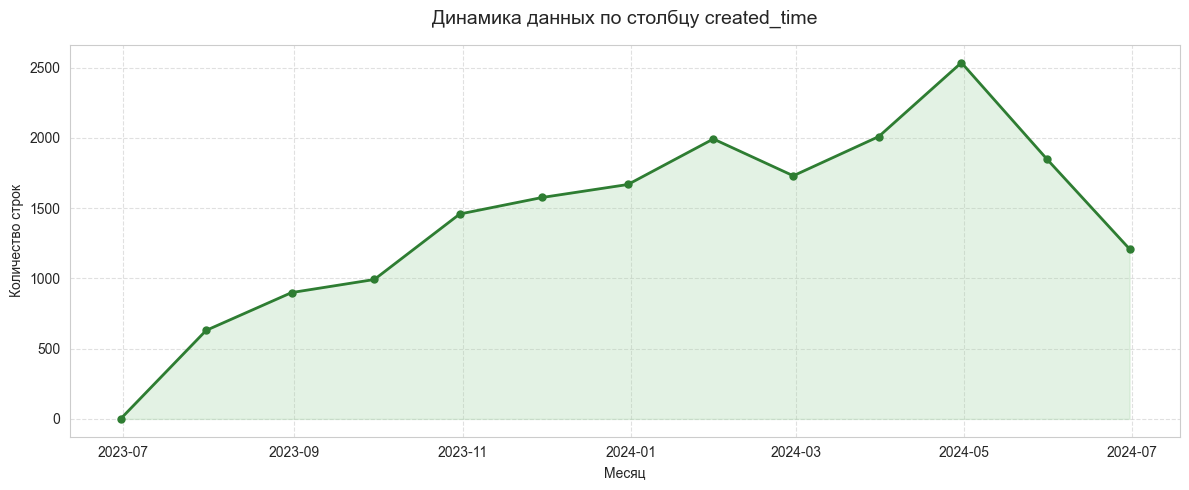


────────────────────────────────────────────────────────────
📊 АНАЛИЗ ПЕРИОДА: MODIFIED_TIME
────────────────────────────────────────────────────────────
  📅 Диапазон:  2023-07-06 — 2024-06-21
  ⏳ Длительность: 351 дней
  🚫 Пропуски:   0


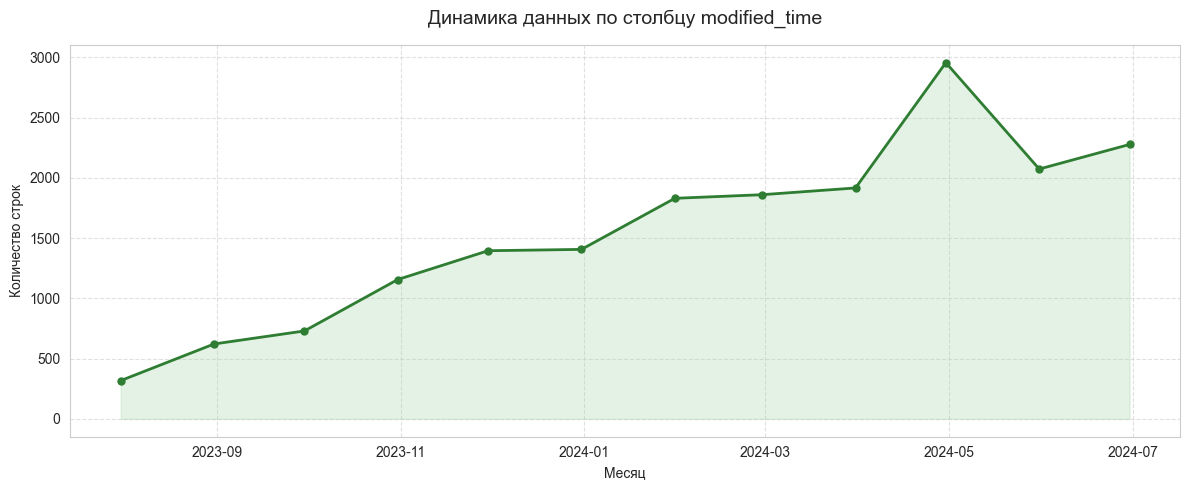

In [29]:
for col in dataset_config['date_cols']:
    if col not in df.columns:
        continue

    print(f"\n{'─'*60}")
    print(f"📊 АНАЛИЗ ПЕРИОДА: {col.upper()}")
    print(f"{'─'*60}")

    # Расширенная статистика
    min_date = df[col].min()
    max_date = df[col].max()
    days_range = (max_date - min_date).days
    
    print(f"  📅 Диапазон:  {min_date.date()} — {max_date.date()}")
    print(f"  ⏳ Длительность: {days_range} дней")
    print(f"  🚫 Пропуски:   {df[col].isnull().sum()}")

    # Временной ряд по месяцам (явно заполняем пропуски нулями)
    monthly = df.set_index(col).resample('ME').size().fillna(0)

    # Визуализация
    plt.figure(figsize=(12, 5))
    plt.plot(monthly.index, monthly.values, 
             marker='o', markersize=5, 
             linewidth=2, color='#2E7D32', # Темно-зеленый цвет
             label='Кол-во записей')
    
    plt.title(f"Динамика данных по столбцу {col}", fontsize=14, pad=15)
    plt.ylabel("Количество строк")
    plt.xlabel("Месяц")
    
    # Добавляем сетку для читаемости
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Заливка области под графиком для красоты
    plt.fill_between(monthly.index, monthly.values, color='#A5D6A7', alpha=0.3)

    plt.tight_layout()
    
    # Сохранение
    plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_timeseries.png", 
                dpi=150, bbox_inches='tight')
    plt.show()

### 📊 Одномерный анализ временных рядов (Contacts)

В таблице контактов мы проанализировали две ключевые даты: когда человек попал в систему (`created_time`) и когда по нему были последние изменения (`modified_time`).

#### 📝 Микровывод

1. **CREATED_TIME (Регистрация):**
    * **Годовой цикл:** База охватывает ровно **360 дней** (почти идеальный календарный год). Это подтверждает, что мы анализируем свежий и актуальный поток клиентов.
    * **Высокая точность:** У нас **17 921 уникальное время создания** на 18 548 контактов. Это значит, что новые люди приходят в CRM практически каждую минуту в течение рабочего дня.
    * **Старт системы:** Сбор контактов начался 27 июня 2023 года — это важная точка отсчета для всего проекта.

2. **MODIFIED_TIME (Активность):**
    * **Постоянная работа:** Период модификаций практически совпадает с периодом создания. Это говорит о том, что менеджеры работают с базой "здесь и сейчас".
    * **Свежесть базы:** Максимальная дата изменения (21 июня 2024) совпадает с датой последнего созданного контакта. Это значит, что данные выгружены из активно работающей CRM, а не из старого архива.
    * **Плотность изменений:** Тот факт, что уникальных дней модификации (16 580) меньше, чем уникальных дней создания, подтверждает: с одним контактом могут работать несколько раз в разные дни, либо в определенные дни проводятся массовые обновления статусов.

3. **Сравнение с таблицей Deals:**
    * В `Deals` мы видели "хвосты" из 2022 года. В `Contacts` же все начинается с лета 2023. 
    * *Вывод для джуна:* Скорее всего, в таблицу `Contacts` попали только те люди, по которым велась активность за последний год, в то время как в сделках могли сохраниться старые "карточки" для истории оплат.

#### 🛠 Решения
* **Расчет «свежести»:** Стоит создать признак `days_since_modification` (текущая дата минус `modified_time`), чтобы найти контакты, с которыми давно не связывались.
* **Группировка по часам:** Как и в сделках, извлечь `hour` из `created_time`, чтобы сопоставить пики регистрации людей с пиками создания сделок.
* **Синхронизация:** Использовать этот год (23/24) как основной для анализа маркетинговой эффективности.

In [30]:
#### 💻 Код реализации

# Добавляем стандартные временные признаки
df['created_month'] = df['created_time'].dt.month
df['created_day_of_week'] = df['created_time'].dt.day_name()
df['created_hour'] = df['created_time'].dt.hour

# Считаем разницу между созданием и последним изменением (интенсивность работы)
df['days_to_modify'] = (df['modified_time'] - df['created_time']).dt.days

print("✅ Временные признаки для контактов успешно созданы.")

✅ Временные признаки для контактов успешно созданы.


---
## 13. Сохранение

Сохраняем очищенный датасет в `data/processed/` как parquet.  
Если файл с таким именем уже существует - перекладываем его в `data/processed/backup/` с датой и временем.  
Конфиг обновляется в `data/processed/`.

In [31]:
sufix = 'cleaned'

dataset_path = PROCESSED / f"{dataset_config['name']}_{sufix}.xlsx"

# Если файл уже есть - бэкапим его перед перезаписью
if dataset_path.exists():
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    backup_path = BACKUP / f"{dataset_config['name']}_{sufix}_{timestamp}.xlsx"
    dataset_path.rename(backup_path)
    print(f"Предыдущий файл -> бэкап: {backup_path.name}")

# Сохраняем очищенный датасет
df.to_excel(dataset_path, index=False)
print(f"Датасет сохранён:  {dataset_path}")
print(f"Размер:            {df.shape[0]} строк × {df.shape[1]} столбцов")

Предыдущий файл -> бэкап: contacts_cleaned_20260416_0743.xlsx
Датасет сохранён:  E:\ICH\Python Data analyse\crm\data\processed\contacts_cleaned.xlsx
Размер:            18548 строк × 8 столбцов


In [32]:
# Сохраняем обновлённый конфиг
with open(config_path, 'wb') as f:
    pickle.dump(dataset_config, f)

print(f"Конфиг сохранён: {config_path}")
print()
print("Итоговый конфиг:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Конфиг сохранён: E:\ICH\Python Data analyse\crm\data\processed\contacts_config.pkl

Итоговый конфиг:
  name: contacts
  filename: Contacts (Done).xlsx
  num_cols: []
  cat_cols: []
  bool_cols: []
  date_cols: ['created_time', 'modified_time']
  drop_cols: []
  id_cols: ['id']


In [33]:
# Проверяем что всё сохранилось
print("Содержимое папки processed/:")
for f in sorted(PROCESSED.glob('*')):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}  ({size_kb:.1f} KB)")

print()
print("Содержимое папки backup/:")
for f in sorted(BACKUP.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.1f} KB)")

Содержимое папки processed/:
  calls_cleaned.xlsx  (7882.1 KB)
  calls_config.pkl  (0.3 KB)
  contacts_cleaned.xlsx  (778.5 KB)
  contacts_config.pkl  (0.2 KB)
  crm_analysis.xlsx  (5522.7 KB)
  deals_cleaned.xlsx  (3704.6 KB)
  deals_config.pkl  (0.4 KB)
  FINAL_UE_DATA.csv  (11616.2 KB)
  spend_cleaned.xlsx  (728.6 KB)
  spend_config.pkl  (0.2 KB)

Содержимое папки backup/:
  calls_cleaned_20260331_1907.xlsx  (4714.7 KB)
  calls_cleaned_20260331_2055.xlsx  (4714.7 KB)
  calls_cleaned_20260331_2115.xlsx  (4714.7 KB)
  calls_cleaned_20260402_2208.xlsx  (5509.2 KB)
  calls_cleaned_20260410_0900.xlsx  (5925.0 KB)
  calls_cleaned_20260411_1732.xlsx  (5925.0 KB)
  calls_cleaned_20260411_2144.xlsx  (7882.1 KB)
  calls_cleaned_20260413_1156.xlsx  (7882.1 KB)
  calls_cleaned_20260414_0853.xlsx  (7882.1 KB)
  calls_cleaned_20260414_1211.xlsx  (7882.1 KB)
  calls_cleaned_20260414_1708.xlsx  (7882.1 KB)
  calls_cleaned_20260415_0859.xlsx  (7882.1 KB)
  contacts_cleaned_20260323_2036.xlsx  (480.2

---
## 14. Зависимости окружения

In [34]:
!pip freeze > "{dataset_config['name']}_requirements.txt"

---
## 15. Итоговые описательные статистики

In [35]:
# можно загрузить из PROCESSED, чтобы убедиться, что сохранили все верно 
dataset_path

WindowsPath('E:/ICH/Python Data analyse/crm/data/processed/contacts_cleaned.xlsx')

In [36]:
print(df.dtypes)

id                     string[python]
contact_owner_name             object
created_time           datetime64[ns]
modified_time          datetime64[ns]
created_month                   int32
created_day_of_week            object
created_hour                    int32
days_to_modify                  int64
dtype: object


In [37]:
df.describe(include='all')

,id,contact_owner_name,created_time,modified_time,created_month,created_day_of_week,created_hour,days_to_modify
count,18548,18548,18548,18548,18548.00,18548,18548.00,18548.00
unique,18548,28,NaN,NaN,NaN,7,NaN,NaN
top,5805028000000645014,Charlie Davis,NaN,NaN,NaN,Wednesday,NaN,NaN
freq,1,2018,NaN,NaN,NaN,2912,NaN,NaN
mean,NaN,NaN,2024-01-24 14:00:21.679965696,2024-02-15 07:41:24.814535168,5.96,NaN,13.99,21.49
min,NaN,NaN,2023-06-27 11:28:00,2023-07-06 10:54:00,1.00,NaN,0.00,0.00
25%,NaN,NaN,2023-11-15 16:40:45,2023-12-09 12:43:00,3.00,NaN,10.00,0.00
50%,NaN,NaN,2024-02-01 18:30:00,2024-02-28 22:21:30,5.00,NaN,14.00,0.00
75%,NaN,NaN,2024-04-12 16:37:15,2024-04-26 22:02:30,10.00,NaN,19.00,6.00
max,NaN,NaN,2024-06-21 15:30:00,2024-06-21 15:32:00,12.00,NaN,23.00,350.00


In [38]:
# Сводная таблица по datetime столбцам 
h.descr_df(df, include=['datetime'], show_stats=True, show_sample_rows=True)

,Название признака,Тип данных,Количество значений,Пропуски (NaN),Уникальных значений,Пример строка 1,Пример строка 2,Пример строка 3
0,created_time,datetime64[ns],18548,0,17921,2023-06-27 11:28:00,2023-07-03 11:31:00,2023-07-02 22:37:00
1,modified_time,datetime64[ns],18548,0,16580,2023-12-22 13:34:00,2024-05-21 10:23:00,2023-12-21 13:17:00


## 🏁 Итоговое резюме по датасету Contacts (Контакты)

Таблица **Contacts** является эталонным справочником нашего проекта. В отличие от транзакционных таблиц (Deals), она лишена "шума" и пропусков, что делает её идеальным фундаментом для построения сквозной аналитики.

### 📝 Глобальные выводы по данным:

1. **Техническое совершенство:** * В датасете **18 548 записей**, и в них **0% пропусков**. 
    * Поле `id` полностью уникально (18 548 уникальных значений), что гарантирует отсутствие дубликатов при объединении с таблицами сделок и звонков.
2. **Временной охват (Retention & Activity):**
    * База охватывает ровно **один год** (июнь 2023 — июнь 2024). 
    * Среднее время жизни контакта (разница между созданием и изменением) составляет около **22 дней**. Это указывает на то, что работа с лидом в среднем ведется около трех недель, прежде чем он либо переходит в сделку, либо уходит в архив.
3. **Операционный фокус:**
    * **Charlie Davis** лидирует по количеству контактов (2018), что подтверждает его статус "флагманского" менеджера, работающего с самым большим объемом входящего трафика.
    * Наличие **28 владельцев контактов** (против 18 в сделках) говорит о том, что часть сотрудников занимается только первичной регистрацией или квалификацией лидов, не доводя их до этапа продажи.

### 🚀 Как мы будем использовать этот датасет дальше:

* **Мастер-ключ для Merge:** Этот датасет станет основной для объединения с `Deals`. Мы сможем вычислить «конверсию в сделку» — какой процент людей из базы вообще дошел до создания предметного интереса.
* **Анализ скорости реакции:** Сравнивая `created_time` из Contacts с временем первого звонка из таблицы `Calls`, мы рассчитаем критически важную метрику **First Response Time**.
* **Сегментация по активности:** На основе разницы между `created_time` и `modified_time` мы выделим сегмент «активных» клиентов для дальнейшего анализа их поведения в воронке продаж.

**Статус:** База контактов валидирована, очищена и готова к интеграции в общую модель данных.